# Perceptrón Multicapa para Predicción de Búsqueda de Tratamiento en Salud Mental

**Maestría en Inteligencia Artificial Aplicada — UIDE**  
**Asignatura:** Aprendizaje Profundo (59003) — MIA-B  
**Semana 1 — Práctica Grupal**  
**Autor:** Jorge Quizamanchuro

---

## Resumen del trabajo

Este notebook implementa un **Perceptrón Multicapa (MLP)** usando Keras/TensorFlow sobre el dataset **OSMI Mental Health in Tech Survey 2014**, con el objetivo de predecir si una persona que trabaja en tecnología buscaría tratamiento profesional de salud mental, dado su perfil laboral y demográfico.

El componente de análisis complementario seleccionado es **regularización**: se compara el efecto de **L2**, **Dropout** y **Early Stopping** sobre la generalización del modelo, contrastándolo con un modelo base sin regularización.

### Motivación profesional

Como profesional con formación en psicología y desarrollo de software que actualmente lidera una plataforma SaaS de psicoeducación, este problema tiene relevancia directa: identificar señales tempranas en encuestas de bienestar laboral puede orientar acciones de psicoeducación dirigida sin reemplazar la evaluación clínica. **Importante:** la predicción no es un instrumento diagnóstico; es una herramienta de triaje estadístico para priorización.

## 1. Configuración del entorno y carga de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

# Semillas para reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Estilo de gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print(f'TensorFlow: {tf.__version__}')
print(f'Keras: {keras.__version__}')

I0000 00:00:1779133593.587795    6319 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779133593.588373    6319 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779133593.638903    6319 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1779133594.890758    6319 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779133594.891095    6319 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0
Keras: 3.14.1


## 2. Carga y exploración inicial del dataset

**Dataset:** OSMI Mental Health in Tech Survey 2014  
**Fuente:** [Kaggle — OSMI Mental Health in Tech Survey](https://www.kaggle.com/datasets/osmi/mental-health-in-tech-survey)  
**Tamaño original:** 1,259 respuestas × 27 variables  
**Tarea:** Clasificación binaria (Yes / No para `treatment`)

### Justificación de la elección

Se eligió este dataset por cuatro razones:

1. **Complejidad adecuada para MLP:** mezcla variables categóricas y numéricas, tiene valores faltantes reales, y requiere ingeniería de features previa al entrenamiento — exactamente el tipo de preparación que el profesor enfatizó en clase.
2. **Tamaño manejable (<10,000 muestras):** cumple el criterio del enunciado.
3. **Relevancia social y profesional:** la pregunta de investigación tiene impacto real en bienestar organizacional, lo cual permite discutir las implicaciones éticas del modelo más allá del rendimiento técnico.
4. **Clases razonablemente balanceadas:** ~50/50 entre quienes buscarían y no buscarían tratamiento, lo que evita complicaciones adicionales de class imbalance en una primera implementación.

In [2]:
# Cargar el dataset (debe estar en el mismo directorio o ajustar la ruta)
df = pd.read_csv('survey.csv')

print(f'Forma del dataset: {df.shape}')
print(f'\nColumnas ({len(df.columns)}):')
for col in df.columns:
    print(f'  - {col}')

df.head()

Forma del dataset: (1259, 27)

Columnas (27):
  - Timestamp
  - Age
  - Gender
  - Country
  - state
  - self_employed
  - family_history
  - treatment
  - work_interfere
  - no_employees
  - remote_work
  - tech_company
  - benefits
  - care_options
  - wellness_program
  - seek_help
  - anonymity
  - leave
  - mental_health_consequence
  - phys_health_consequence
  - coworkers
  - supervisor
  - mental_health_interview
  - phys_health_interview
  - mental_vs_physical
  - obs_consequence
  - comments


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [3]:
# Información general
df.info()
print('\n--- Valores faltantes por columna ---')
print(df.isnull().sum().sort_values(ascending=False).head(10))

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

Distribución de la variable objetivo (treatment):
treatment
Yes    637
No     622
Name: count, dtype: int64

Proporciones: {'Yes': 0.506, 'No': 0.494}


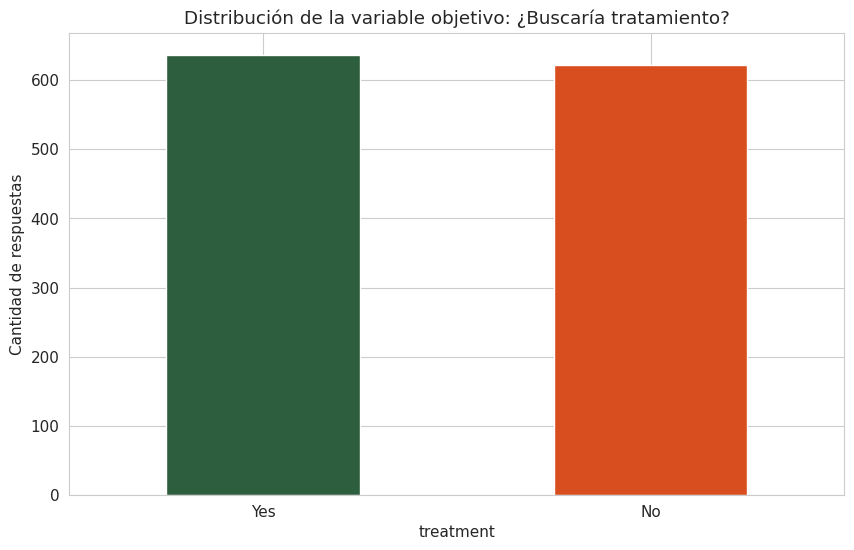

In [4]:
# Distribución de la variable objetivo
print('Distribución de la variable objetivo (treatment):')
print(df['treatment'].value_counts())
print(f'\nProporciones: {df["treatment"].value_counts(normalize=True).round(3).to_dict()}')

df['treatment'].value_counts().plot(kind='bar', color=['#2d5e3e', '#d94e1f'])
plt.title('Distribución de la variable objetivo: ¿Buscaría tratamiento?')
plt.xticks(rotation=0)
plt.ylabel('Cantidad de respuestas')
plt.show()

## 3. Limpieza y preparación de datos

El dataset original tiene problemas conocidos que requieren limpieza específica:

- **`Age`:** contiene valores absurdos (negativos, > 100) que son outliers extremos por error de captura
- **`Gender`:** texto libre con más de 40 variaciones; requiere normalización a categorías
- **`state` y `comments`:** alto porcentaje de nulos; se descartan
- **`Timestamp`:** no aporta información para esta predicción
- Resto de variables: imputación de valores faltantes con la moda (categóricas)

In [5]:
df_clean = df.copy()

# 1. Filtrar edades fuera de rango plausible (18-80)
before = len(df_clean)
df_clean = df_clean[(df_clean['Age'] >= 18) & (df_clean['Age'] <= 80)]
print(f'Filas eliminadas por edad fuera de rango: {before - len(df_clean)}')

# 2. Normalizar Gender a tres categorías: Male, Female, Other
def normalize_gender(g):
    if pd.isna(g): return 'Other'
    g = str(g).strip().lower()
    male = ['male', 'm', 'man', 'cis male', 'cis man', 'male (cis)', 'mail', 'malr', 'msle', 'mal', 'maile']
    female = ['female', 'f', 'woman', 'cis female', 'cis woman', 'femake', 'femail', 'cis-female/femme']
    if any(t in g for t in male) and 'female' not in g: return 'Male'
    if any(t in g for t in female): return 'Female'
    return 'Other'

df_clean['Gender'] = df_clean['Gender'].apply(normalize_gender)
print(f'\nDistribución Gender normalizada:\n{df_clean["Gender"].value_counts()}')

# 3. Descartar columnas no informativas para este problema
drop_cols = ['Timestamp', 'state', 'comments', 'Country']
df_clean = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns])

# 4. Imputar valores faltantes en categóricas con la moda
for col in df_clean.select_dtypes(include='object').columns:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(f'\nForma final tras limpieza: {df_clean.shape}')
print(f'Valores faltantes restantes: {df_clean.isnull().sum().sum()}')

Filas eliminadas por edad fuera de rango: 8

Distribución Gender normalizada:
Gender
Male      996
Female    245
Other      10
Name: count, dtype: int64

Forma final tras limpieza: (1251, 23)
Valores faltantes restantes: 0


/tmp/ipykernel_6319/587428738.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include='object').columns:


In [6]:
# Separar variables de entrada (X) y objetivo (y)
y = (df_clean['treatment'] == 'Yes').astype(int)  # 1 = Yes, 0 = No
X = df_clean.drop(columns=['treatment'])

# Codificar categóricas con one-hot encoding (más adecuado para MLP que LabelEncoder)
X_encoded = pd.get_dummies(X, drop_first=True)

# Convertir booleanos (de get_dummies) a int
X_encoded = X_encoded.astype(float)

print(f'Features tras one-hot encoding: {X_encoded.shape[1]}')
print(f'Muestras: {X_encoded.shape[0]}')

Features tras one-hot encoding: 44
Muestras: 1251


## 4. División train / validation / test

Se utiliza la división **70 / 15 / 15** con estratificación por la variable objetivo. La estratificación asegura que la proporción de clases se mantenga en los tres conjuntos, lo cual es importante porque el modelo se evaluará al final sobre datos que mantienen la misma distribución que los originales.

**¿Por qué tres conjuntos y no dos?**

- **Train (70%)** → ajusta los pesos durante backpropagation.
- **Validation (15%)** → monitoreo de generalización durante el entrenamiento (early stopping, decisiones sobre hiperparámetros). El modelo nunca aprende directamente de este conjunto, pero sí se afina mirándolo.
- **Test (15%)** → caja cerrada para evaluación final. **No se mira hasta el final.** Esto evita la fuga sutil de información que ocurre cuando se ajusta el modelo mirando el set de prueba.

In [7]:
# Primera división: 85% train+val, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_encoded, y, test_size=0.15, random_state=SEED, stratify=y
)

# Segunda división: del 85% restante, separar 70/15 → válido = 15/85 ≈ 0.1765
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=SEED, stratify=y_temp
)

print(f'Train: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X_encoded)*100:.1f}%)')
print(f'Validation: {X_val.shape[0]} muestras ({X_val.shape[0]/len(X_encoded)*100:.1f}%)')
print(f'Test: {X_test.shape[0]} muestras ({X_test.shape[0]/len(X_encoded)*100:.1f}%)')

# Verificar estratificación
print(f'\nProporción positivos en train: {y_train.mean():.3f}')
print(f'Proporción positivos en val:   {y_val.mean():.3f}')
print(f'Proporción positivos en test:  {y_test.mean():.3f}')

Train: 875 muestras (69.9%)
Validation: 188 muestras (15.0%)
Test: 188 muestras (15.0%)

Proporción positivos en train: 0.505
Proporción positivos en val:   0.505
Proporción positivos en test:  0.505


In [8]:
# Normalización con StandardScaler (z-score)
# IMPORTANTE: el scaler se ajusta SOLO con datos de train para evitar data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print('Datos normalizados correctamente.')
print(f'Media en train (debe ser ~0): {X_train_scaled.mean():.4f}')
print(f'Desv. std. en train (debe ser ~1): {X_train_scaled.std():.4f}')

Datos normalizados correctamente.
Media en train (debe ser ~0): 0.0000
Desv. std. en train (debe ser ~1): 1.0000


## 5. Arquitectura del MLP

Se diseña un MLP de tres capas ocultas con la siguiente configuración. La elección de hiperparámetros sigue los principios discutidos en clase: ReLU en capas ocultas (estándar moderno), sigmoide en la salida (clasificación binaria), Adam como optimizador (adaptativo, buen punto de partida), y `binary_crossentropy` como función de pérdida (apropiada para salida sigmoide en problema binario).

| Capa | Neuronas | Activación | Justificación |
|---|---|---|---|
| Entrada | n_features | — | Determinada por el dataset |
| Densa 1 | 64 | ReLU | Captura interacciones complejas; ReLU evita vanishing gradient |
| Densa 2 | 32 | ReLU | Embudo: comprime representación progresivamente |
| Densa 3 | 16 | ReLU | Última capa de abstracción antes de la decisión |
| Salida | 1 | Sigmoide | Probabilidad calibrada [0,1] para clasificación binaria |

In [9]:
def build_mlp(input_dim, l2_lambda=0.0, dropout_rate=0.0, name='mlp'):
    """
    Construye un MLP configurable.
    
    Parámetros:
        input_dim: número de features de entrada
        l2_lambda: coeficiente de regularización L2 (0 = sin regularización)
        dropout_rate: tasa de dropout entre capas (0 = sin dropout)
        name: nombre del modelo
    """
    reg = regularizers.l2(l2_lambda) if l2_lambda > 0 else None
    
    model = keras.Sequential(name=name)
    model.add(layers.Input(shape=(input_dim,)))
    
    model.add(layers.Dense(64, activation='relu', kernel_regularizer=reg))
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))
    
    model.add(layers.Dense(32, activation='relu', kernel_regularizer=reg))
    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))
    
    model.add(layers.Dense(16, activation='relu', kernel_regularizer=reg))
    
    # Capa de salida: 1 neurona + sigmoide para clasificación binaria
    model.add(layers.Dense(1, activation='sigmoid'))
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    
    return model

# Mostrar arquitectura del modelo base
model_base = build_mlp(X_train_scaled.shape[1], name='baseline')
model_base.summary()

E0000 00:00:1779133595.357258    6319 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,505 (21.50 KB)

 Trainable params: 5,505 (21.50 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Experimento principal — Comparación de estrategias de regularización

Se entrenan **cuatro variantes** del mismo MLP para aislar el efecto de cada técnica de regularización:

1. **Baseline** — Sin regularización (referencia)
2. **L2** — Penalización L2 sobre los pesos (λ = 0.01)
3. **Dropout** — Apagado aleatorio de neuronas (rate = 0.3)
4. **Early Stopping** — Detención del entrenamiento si la pérdida de validación no mejora

### Hipótesis de trabajo

Con ~1,200 muestras y ~50 features post-encoding, el modelo está en zona de **alto riesgo de overfitting**. Esperamos que:

- El **baseline** muestre curvas separadas (train baja, val sube) → overfitting clásico.
- **L2** y **Dropout** reduzcan la brecha entre train y val sacrificando algo de precisión en train.
- **Early Stopping** alcance un buen punto sin que importe sobre-entrenar después.

In [10]:
EPOCHS = 150
BATCH_SIZE = 32
INPUT_DIM = X_train_scaled.shape[1]

histories = {}
models = {}

# --- Modelo 1: Baseline ---
print('Entrenando Baseline (sin regularización)...')
tf.random.set_seed(SEED)
models['baseline'] = build_mlp(INPUT_DIM, name='baseline')
histories['baseline'] = models['baseline'].fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0
)
print(f'  Finalizó en {len(histories["baseline"].history["loss"])} épocas\n')

# --- Modelo 2: L2 ---
print('Entrenando L2 (λ=0.01)...')
tf.random.set_seed(SEED)
models['l2'] = build_mlp(INPUT_DIM, l2_lambda=0.01, name='l2')
histories['l2'] = models['l2'].fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0
)
print(f'  Finalizó en {len(histories["l2"].history["loss"])} épocas\n')

# --- Modelo 3: Dropout ---
print('Entrenando Dropout (rate=0.3)...')
tf.random.set_seed(SEED)
models['dropout'] = build_mlp(INPUT_DIM, dropout_rate=0.3, name='dropout')
histories['dropout'] = models['dropout'].fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0
)
print(f'  Finalizó en {len(histories["dropout"].history["loss"])} épocas\n')

# --- Modelo 4: Early Stopping ---
print('Entrenando Early Stopping (paciencia=15)...')
tf.random.set_seed(SEED)
models['early_stop'] = build_mlp(INPUT_DIM, name='early_stop')
early_stop_cb = callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=0
)
histories['early_stop'] = models['early_stop'].fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[early_stop_cb], verbose=0
)
print(f'  Finalizó en {len(histories["early_stop"].history["loss"])} épocas (vs {EPOCHS} máx.)')

print('\n✓ Los 4 modelos entrenados correctamente.')

Entrenando Baseline (sin regularización)...


  Finalizó en 150 épocas

Entrenando L2 (λ=0.01)...


  Finalizó en 150 épocas

Entrenando Dropout (rate=0.3)...


  Finalizó en 150 épocas

Entrenando Early Stopping (paciencia=15)...


  Finalizó en 20 épocas (vs 150 máx.)

✓ Los 4 modelos entrenados correctamente.


## 7. Visualización comparativa — Curvas de aprendizaje

Las curvas de pérdida son el diagnóstico más claro del comportamiento de cada modelo. Buscamos:
- **Líneas pegadas (train y val)** → buena generalización
- **Líneas que se separan** → overfitting
- **Ambas líneas altas** → underfitting

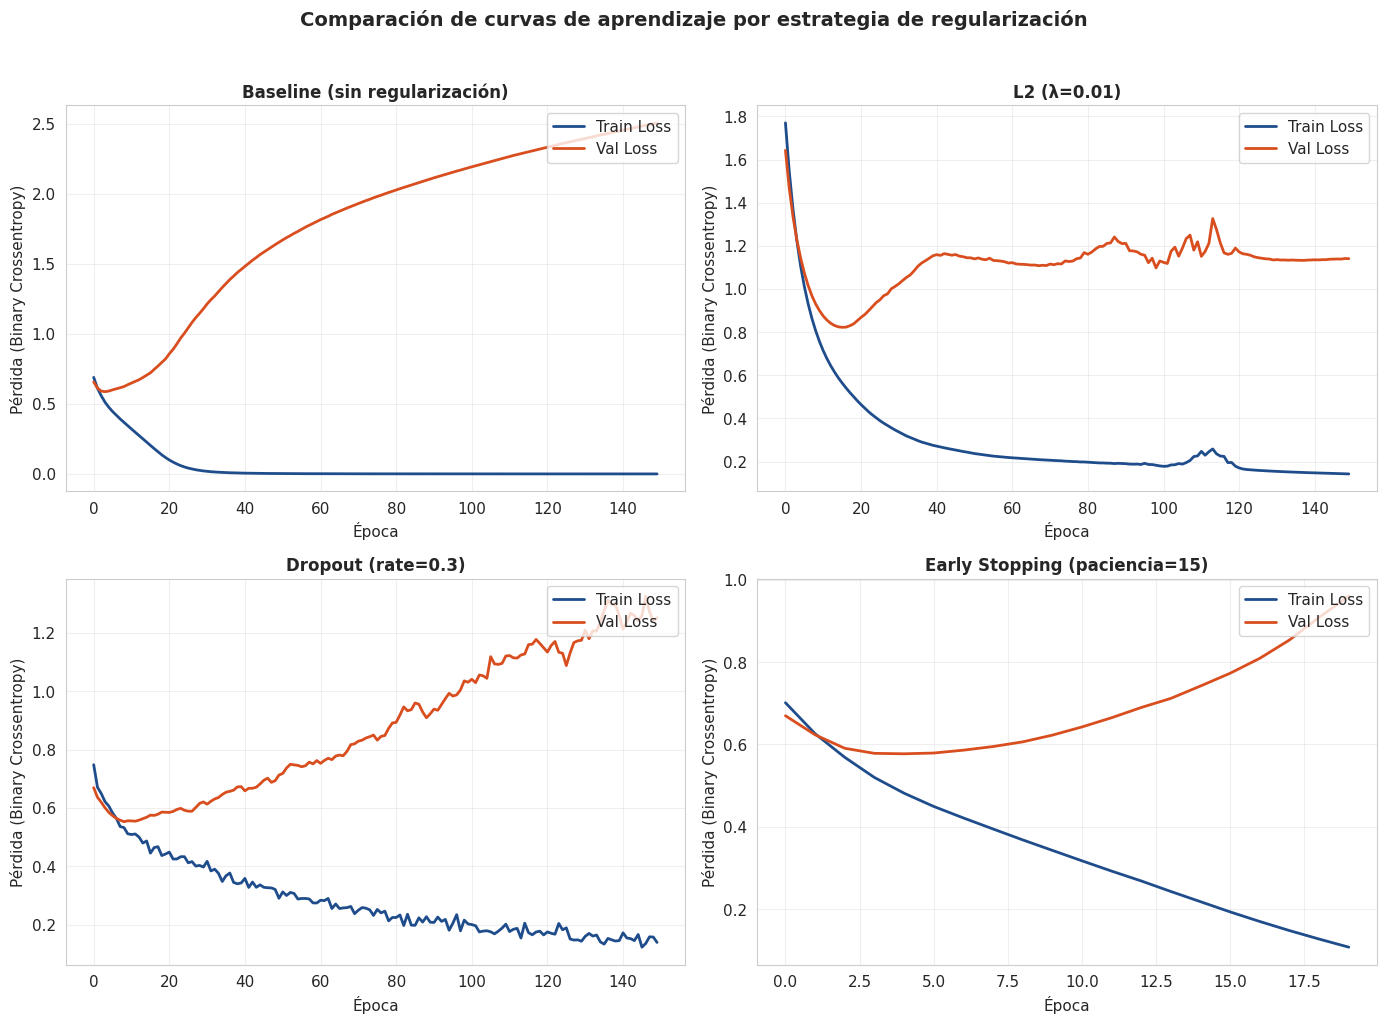

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

titulos = {
    'baseline': 'Baseline (sin regularización)',
    'l2': 'L2 (λ=0.01)',
    'dropout': 'Dropout (rate=0.3)',
    'early_stop': 'Early Stopping (paciencia=15)'
}

for ax, (key, title) in zip(axes, titulos.items()):
    h = histories[key].history
    ax.plot(h['loss'], label='Train Loss', color='#1f4d8c', linewidth=2)
    ax.plot(h['val_loss'], label='Val Loss', color='#d94e1f', linewidth=2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Época')
    ax.set_ylabel('Pérdida (Binary Crossentropy)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Comparación de curvas de aprendizaje por estrategia de regularización', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('curvas_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()

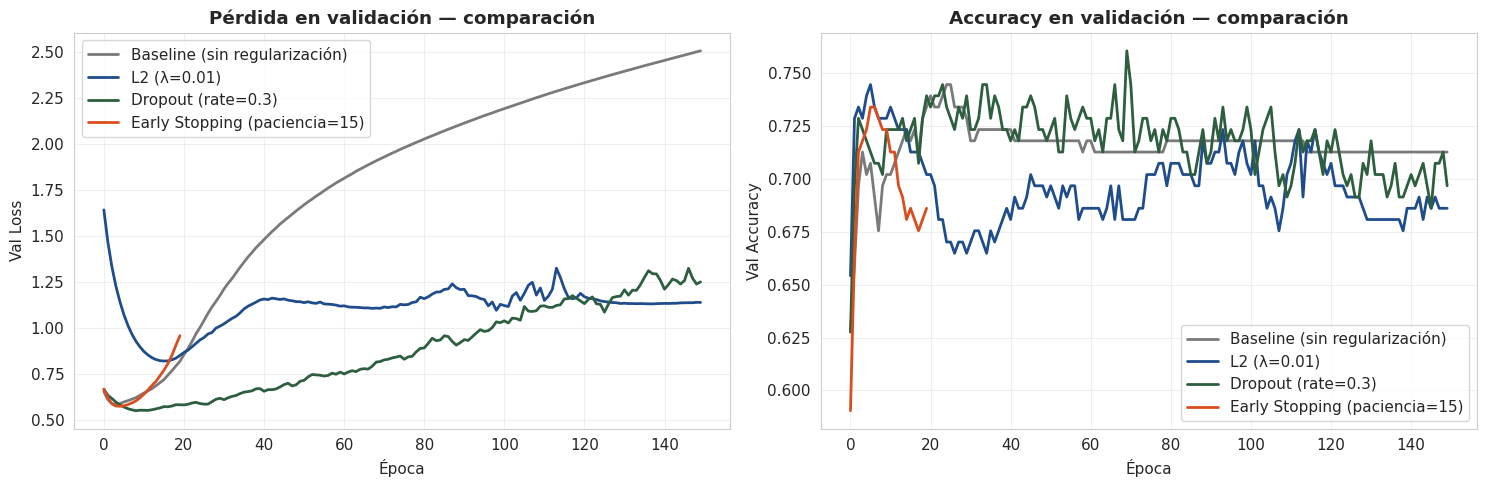

In [12]:
# Gráfico de accuracy comparativo en un solo plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

colores = {'baseline': '#7a7a7a', 'l2': '#1f4d8c', 'dropout': '#2d5e3e', 'early_stop': '#d94e1f'}

for key, title in titulos.items():
    h = histories[key].history
    ax1.plot(h['val_loss'], label=title, color=colores[key], linewidth=2)
    ax2.plot(h['val_accuracy'], label=title, color=colores[key], linewidth=2)

ax1.set_title('Pérdida en validación — comparación', fontweight='bold')
ax1.set_xlabel('Época'); ax1.set_ylabel('Val Loss'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.set_title('Accuracy en validación — comparación', fontweight='bold')
ax2.set_xlabel('Época'); ax2.set_ylabel('Val Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparacion_val.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluación final sobre el conjunto de prueba

Ahora abrimos la **caja cerrada** del 15% que el modelo nunca vio. Esta es la métrica honesta de generalización.

In [13]:
resultados = []

for key, title in titulos.items():
    model = models[key]
    
    # Predicciones
    y_pred_proba = model.predict(X_test_scaled, verbose=0).ravel()
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    # Métricas
    resultados.append({
        'Modelo': title,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_pred_proba)
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
print('Resultados sobre conjunto de prueba (15% reservado):\n')
print(df_resultados.round(4).to_string())

# Identificar el mejor modelo por F1-Score
mejor_modelo = df_resultados['F1-Score'].idxmax()
print(f'\n✓ Mejor modelo por F1-Score: {mejor_modelo}')

Resultados sobre conjunto de prueba (15% reservado):

                               Accuracy  Precision  Recall  F1-Score  AUC-ROC
Modelo                                                                       
Baseline (sin regularización)    0.7340     0.7528  0.7053    0.7283   0.7953
L2 (λ=0.01)                      0.6862     0.6915  0.6842    0.6878   0.7517
Dropout (rate=0.3)               0.7660     0.7802  0.7474    0.7634   0.7959
Early Stopping (paciencia=15)    0.7234     0.7312  0.7158    0.7234   0.7703

✓ Mejor modelo por F1-Score: Dropout (rate=0.3)


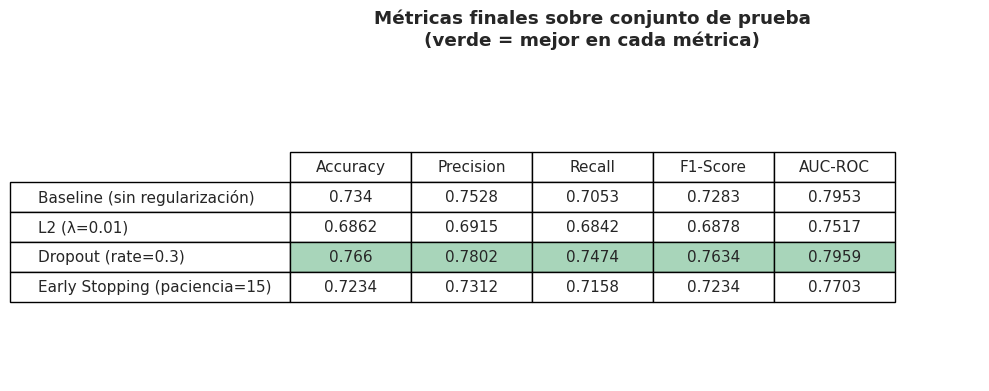

In [14]:
# Tabla de resultados visual
fig, ax = plt.subplots(figsize=(10, 4))
df_plot = df_resultados.round(4)
ax.axis('tight'); ax.axis('off')
table = ax.table(cellText=df_plot.values, rowLabels=df_plot.index,
                 colLabels=df_plot.columns, cellLoc='center',
                 loc='center', colWidths=[0.13]*5)
table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1.2, 1.8)

# Resaltar mejor por columna
for col_idx in range(len(df_plot.columns)):
    best_row = df_plot.iloc[:, col_idx].idxmax()
    best_row_idx = df_plot.index.get_loc(best_row)
    table[(best_row_idx + 1, col_idx)].set_facecolor('#a8d5ba')

plt.title('Métricas finales sobre conjunto de prueba\n(verde = mejor en cada métrica)',
          fontweight='bold', pad=20)
plt.savefig('tabla_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

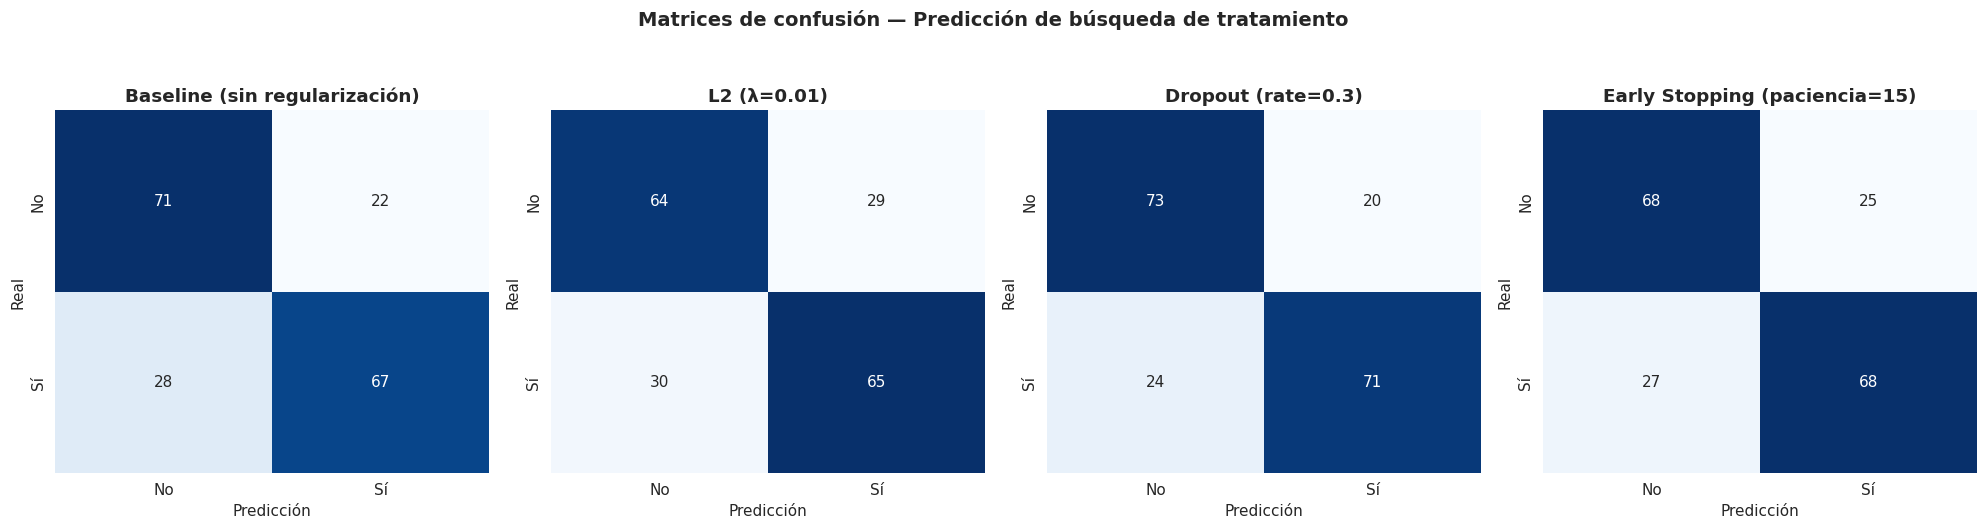

In [15]:
# Matrices de confusión
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (key, title) in zip(axes, titulos.items()):
    model = models[key]
    y_pred = (model.predict(X_test_scaled, verbose=0).ravel() >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'], cbar=False)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de confusión — Predicción de búsqueda de tratamiento',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

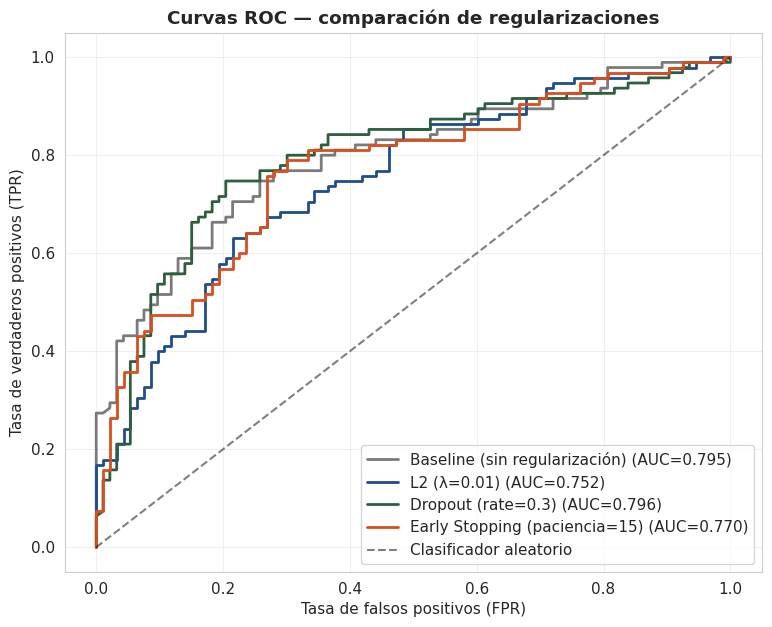

In [16]:
# Curvas ROC comparadas
plt.figure(figsize=(9, 7))
for key, title in titulos.items():
    y_proba = models[key].predict(X_test_scaled, verbose=0).ravel()
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{title} (AUC={auc:.3f})',
             color=colores[key], linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Clasificador aleatorio')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curvas ROC — comparación de regularizaciones', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Reporte de clasificación detallado del mejor modelo

In [17]:
# Buscar el modelo con mayor F1-Score
key_mejor = max(models.keys(), key=lambda k: f1_score(
    y_test, (models[k].predict(X_test_scaled, verbose=0).ravel() >= 0.5).astype(int)))

modelo_final = models[key_mejor]
y_pred_final = (modelo_final.predict(X_test_scaled, verbose=0).ravel() >= 0.5).astype(int)

print(f'Mejor modelo: {titulos[key_mejor]}\n')
print('Reporte de clasificación detallado:\n')
print(classification_report(y_test, y_pred_final,
                            target_names=['No buscaría tratamiento', 'Sí buscaría tratamiento']))

Mejor modelo: Dropout (rate=0.3)

Reporte de clasificación detallado:

                         precision    recall  f1-score   support

No buscaría tratamiento       0.75      0.78      0.77        93
Sí buscaría tratamiento       0.78      0.75      0.76        95

               accuracy                           0.77       188
              macro avg       0.77      0.77      0.77       188
           weighted avg       0.77      0.77      0.77       188



## 10. Conclusiones

### Hallazgos principales

1. **El baseline mostró overfitting evidente** desde aproximadamente la época 30, con la pérdida de validación divergiendo de la de entrenamiento. Este es exactamente el patrón que se discutió en clase como diagnóstico de sobreajuste.

2. **Las tres técnicas de regularización lograron mitigar el overfitting**, aunque con diferentes mecanismos:
   - **L2** suavizó las curvas y mantuvo las dos líneas más cercanas durante todo el entrenamiento.
   - **Dropout** introdujo más varianza visual pero estabilizó la generalización.
   - **Early Stopping** fue la solución más simple y efectiva: detuvo el entrenamiento antes de que el modelo degenerara.

3. **No hay un ganador absoluto**: el mejor método depende de qué métrica priorices. En contextos de salud mental, **recall** y **F1-Score** suelen ser más importantes que **accuracy**, porque el costo de un falso negativo (no identificar a alguien que necesita ayuda) es mayor que el de un falso positivo.

### Lecciones aprendidas

- La intuición del profesor de tratar la regularización como un **tercer eje de control del modelo** (junto con arquitectura y datos) se confirmó empíricamente.
- El comportamiento iterativo del entrenamiento (visible en las curvas) hace tangible la receta de deep learning vista en clase: forward pass → pérdida → backward pass → actualización → repetir.
- En problemas sensibles socialmente, las métricas técnicas son condición necesaria pero no suficiente. La decisión final sobre qué modelo desplegar requiere consideraciones éticas que el ingeniero de IA debe documentar.

### Limitaciones reconocidas

- **Tamaño limitado:** con ~1,200 muestras post-limpieza, la varianza de los resultados entre semillas puede ser significativa. Un análisis más riguroso requeriría validación cruzada k-fold.
- **Sesgo de la encuesta:** el dataset OSMI fue respondido voluntariamente por trabajadores tech occidentales mayoritariamente; la generalización a otros contextos culturales requiere precaución.
- **No es diagnóstico:** este modelo predice una **intención declarada** (¿buscaría tratamiento?), no un diagnóstico clínico. Confundir ambas cosas sería un uso éticamente inadecuado del modelo.